In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.simplefilter(action = "ignore", category = FutureWarning)

In [2]:
data = pd.read_csv("data.csv")

In [3]:
data.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN


In [4]:
data.columns

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')

In [5]:
# Creating Multi-Level Index using id and season
data_indexing = data.set_index(['id','season'])

In [6]:
data_indexing

,,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
id,season,,,,,,,,,,,,,,,,
1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573,2016,Raipur,2016-05-22,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
574,2016,Bangalore,2016-05-24,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
575,2016,Delhi,2016-05-25,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN


In [7]:
# Creating MultiIndex using Season and Player of the Match
data_plyr_season = data.set_index(['season','player_of_match'])

In [8]:
data_plyr_season

id        city        date                  team1  \
season player_of_match                                                       
2008   BB McCullum        1   Bangalore  2008-04-18  Kolkata Knight Riders   
       MEK Hussey         2  Chandigarh  2008-04-19    Chennai Super Kings   
       MF Maharoof        3       Delhi  2008-04-19       Rajasthan Royals   
       MV Boucher         4      Mumbai  2008-04-20         Mumbai Indians   
       DJ Hussey          5     Kolkata  2008-04-20        Deccan Chargers   
...                     ...         ...         ...                    ...   
2016   V Kohli          573      Raipur  2016-05-22       Delhi Daredevils   
       AB de Villiers   574   Bangalore  2016-05-24          Gujarat Lions   
       MC Henriques     575       Delhi  2016-05-25    Sunrisers Hyderabad   
       DA Warner        576       Delhi  2016-05-27          Gujarat Lions   
       BCJ Cutting      577   Bangalore  2016-05-29    Sunrisers Hyderabad   

                                              team2  \
season player_of_match                                
2008   BB McCullum      Royal Challengers Bangalore   
       MEK Hussey                   Kings XI Punjab   
       MF Maharoof                 Delhi Daredevils   
       MV Boucher       Royal Challengers Bangalore   
       DJ Hussey              Kolkata Knight Riders   
...                                             ...   
2016   V Kohli          Royal Challengers Bangalore   
       AB de Villiers   Royal Challengers Bangalore   
       MC Henriques           Kolkata Knight Riders   
       DA Warner                Sunrisers Hyderabad   
       BCJ Cutting      Royal Challengers Bangalore   

                                        toss_winner toss_decision  result  \
season player_of_match                                                      
2008   BB McCullum      Royal Challengers Bangalore         field  normal   
       MEK Hussey               Chennai Super Kings           bat  normal   
       MF Maharoof                 Rajasthan Royals           bat  normal   
       MV Boucher                    Mumbai Indians           bat  normal   
       DJ Hussey                    Deccan Chargers           bat  normal   
...                                             ...           ...     ...   
2016   V Kohli          Royal Challengers Bangalore         field  normal   
       AB de Villiers   Royal Challengers Bangalore         field  normal   
       MC Henriques           Kolkata Knight Riders         field  normal   
       DA Warner                Sunrisers Hyderabad         field  normal   
       BCJ Cutting              Sunrisers Hyderabad           bat  normal   

                        dl_applied                       winner  win_by_runs  \
season player_of_match                                                         
2008   BB McCullum               0        Kolkata Knight Riders          140   
       MEK Hussey                0          Chennai Super Kings           33   
       MF Maharoof               0             Delhi Daredevils            0   
       MV Boucher                0  Royal Challengers Bangalore            0   
       DJ Hussey                 0        Kolkata Knight Riders            0   
...                            ...                          ...          ...   
2016   V Kohli                   0  Royal Challengers Bangalore            0   
       AB de Villiers            0  Royal Challengers Bangalore            0   
       MC Henriques              0          Sunrisers Hyderabad           22   
       DA Warner                 0          Sunrisers Hyderabad            0   
       BCJ Cutting               0          Sunrisers Hyderabad            8   

                        win_by_wickets  \
season player_of_match                   
2008   BB McCullum                   0   
       MEK Hussey                    0   
       MF Maharoof                   9   
       MV Boucher                    5   

In [9]:
# Calculating Season-wise Team Performance Averages
data1=data.groupby(['season','team1','team2'])[['dl_applied','win_by_runs','win_by_wickets']].mean()

In [10]:
data1.head(30)

dl_applied  \
season team1                 team2                                     
2008   Chennai Super Kings   Deccan Chargers                     0.0   
                             Delhi Daredevils                    0.0   
                             Kings XI Punjab                     0.0   
                             Mumbai Indians                      0.0   
                             Rajasthan Royals                    0.0   
                             Royal Challengers Bangalore         0.0   
       Deccan Chargers       Chennai Super Kings                 0.0   
                             Delhi Daredevils                    0.0   
                             Kings XI Punjab                     0.0   
                             Kolkata Knight Riders               0.0   
                             Rajasthan Royals                    0.0   
                             Royal Challengers Bangalore         0.0   
       Delhi Daredevils      Chennai Super Kings                 0.0   
                             Deccan Chargers                     0.0   
                             Kings XI Punjab                     0.5   
                             Rajasthan Royals                    0.0   
                             Royal Challengers Bangalore         0.0   
       Kings XI Punjab       Chennai Super Kings                 0.0   
                             Kolkata Knight Riders               0.0   
                             Mumbai Indians                      0.0   
                             Rajasthan Royals                    0.0   
       Kolkata Knight Riders Chennai Super Kings                 0.5   
                             Deccan Chargers                     0.0   
                             Delhi Daredevils                    0.0   
                             Mumbai Indians                      0.0   
                             Rajasthan Royals                    0.0   
                             Royal Challengers Bangalore         0.0   
       Mumbai Indians        Deccan Chargers                     0.0   
                             Delhi Daredevils                    0.0   
                             Rajasthan Royals                    0.0   

                                                          win_by_runs  \
season team1                 team2                                      
2008   Chennai Super Kings   Deccan Chargers                      0.0   
                             Delhi Daredevils                     0.0   
                             Kings XI Punjab                     25.5   
                             Mumbai Indians                       3.0   
                             Rajasthan Royals                     0.0   
                             Royal Challengers Bangalore         13.0   
       Deccan Chargers       Chennai Super Kings                  0.0   
                             Delhi Daredevils                     0.0   
                             Kings XI Punjab                      0.0   
                             Kolkata Knight Riders                0.0   
                             Rajasthan Royals                     0.0   
                             Royal Challengers Bangalore          0.0   
       Delhi Daredevils      Chennai Super Kings                  0.0   
                             Deccan Chargers                     12.0   
                             Kings XI Punjab                      3.0   
                             Rajasthan Royals                     0.0   
                             Royal Challengers Bangalore         10.0   
       Kings XI Punjab       Chennai Super Kings                  0.0   
                             Kolkata Knight Riders                4.5   
                             Mumbai Indians                      33.5   
                             Rajasthan Royals                    20.5   
       Kolkata Knight Riders Chennai Super Kings                  1.5   
 

In [11]:
print(data.dtypes)

id                   int64
season               int64
city                object
date                object
team1               object
team2               object
toss_winner         object
toss_decision       object
result              object
dl_applied           int64
winner              object
win_by_runs          int64
win_by_wickets       int64
player_of_match     object
venue               object
umpire1             object
umpire2             object
umpire3            float64
dtype: object


In [12]:
# Calculating Total Head-to-Head Matches Between Teams
data2=data.groupby(['team1','team2']).size()

In [13]:
data2.head(30)

team1                team2                      
Chennai Super Kings  Deccan Chargers                 8
                     Delhi Daredevils               11
                     Kings XI Punjab                 9
                     Kochi Tuskers Kerala            2
                     Kolkata Knight Riders          11
                     Mumbai Indians                 10
                     Pune Warriors                   4
                     Rajasthan Royals                9
                     Royal Challengers Bangalore    10
                     Sunrisers Hyderabad             3
Deccan Chargers      Chennai Super Kings             2
                     Delhi Daredevils                8
                     Kings XI Punjab                 7
                     Kochi Tuskers Kerala            1
                     Kolkata Knight Riders           2
                     Mumbai Indians                  5
                     Pune Warriors                   3
                

In [14]:
# Calculating Total Winning Margins Season-wise for Each Team
data5=data.groupby(['season','winner']).sum()[['win_by_runs','win_by_wickets']]

In [15]:
data5.head(30)

win_by_runs  win_by_wickets
season winner                                                  
2008   Chennai Super Kings                   73              29
       Deccan Chargers                        0              17
       Delhi Daredevils                      22              36
       Kings XI Punjab                      123              32
       Kolkata Knight Riders                191               8
       Mumbai Indians                        54              40
       Rajasthan Royals                     225              49
       Royal Challengers Bangalore           17              10
2009   Chennai Super Kings                  262              14
       Deccan Chargers                      114              26
       Delhi Daredevils                      35              49
       Kings XI Punjab                       31              22
       Kolkata Knight Riders                 11              11
       Mumbai Indians                       136               8
       Rajasthan Royals                      80              15
       Royal Challengers Bangalore           95              35
2010   Chennai Super Kings                  162              25
       Deccan Chargers                       71              18
       Delhi Daredevils                     161              17
       Kings XI Punjab                        0              21
       Kolkata Knight Riders                 88              24
       Mumbai Indians                       374              16
       Rajasthan Royals                      84              17
       Royal Challengers Bangalore           36              52
2011   Chennai Super Kings                  217              22
       Deccan Chargers                      196               6
       Delhi Daredevils                      67               7
       Kings XI Punjab                      264              20
       Kochi Tuskers Kerala                  23              30
       Kolkata Knight Riders                 56              32

<Axes: xlabel='winner'>

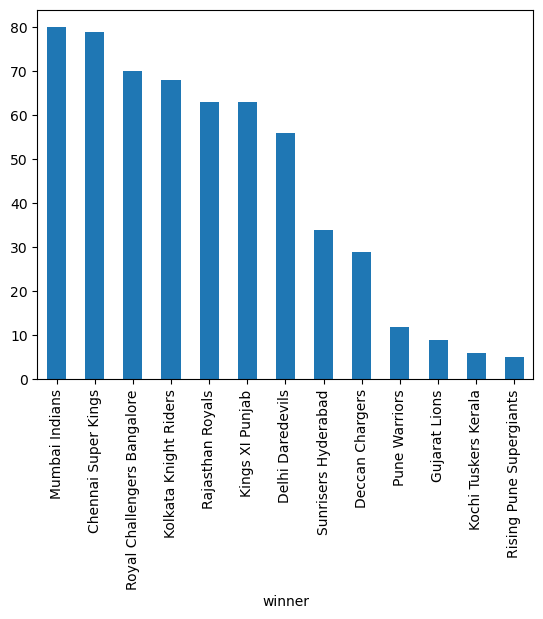

In [16]:
# Visualizing Total Wins by Each Team
data["winner"].value_counts().plot(kind= "bar")

In [19]:
# Analyzing Season-wise Player of the Match Impact on Team Wins
grouped = data.groupby(["season","player_of_match"])["winner"]
winner_by_season = grouped.apply(lambda x: x.value_counts())

print(winner_by_season)

season  player_of_match                             
2008    A Kumble         Royal Challengers Bangalore    1
        A Mishra         Delhi Daredevils               1
        A Nehra          Mumbai Indians                 1
        AC Gilchrist     Deccan Chargers                2
        BB McCullum      Kolkata Knight Riders          1
                                                       ..
2016    SR Watson        Royal Challengers Bangalore    1
        SV Samson        Delhi Daredevils               1
        V Kohli          Royal Challengers Bangalore    4
                         Gujarat Lions                  1
        YK Pathan        Kolkata Knight Riders          2
Name: winner, Length: 395, dtype: int64


In [20]:
# Filtering Matches Where Toss Winner Also Won the Match
a=data.loc[(data["winner"]==data["toss_winner"]),['season','winner','toss_decision']]

In [21]:
a

,season,winner,toss_decision
1,2008,Chennai Super Kings,bat
8,2008,Rajasthan Royals,field
10,2008,Rajasthan Royals,field
12,2008,Deccan Chargers,field
14,2008,Chennai Super Kings,bat
...,...,...,...
570,2016,Gujarat Lions,field
572,2016,Royal Challengers Bangalore,field
573,2016,Royal Challengers Bangalore,field
575,2016,Sunrisers Hyderabad,field


In [22]:
# Calculating Season-wise Toss and Match Win Counts for Each Team
b=a.groupby(['season', 'winner']).count()
b
#a.groupby(['season', 'winner','toss_decision']).count()

#a[a.toss_decision=='bat'].count()

toss_decision
season winner                                    
2008   Chennai Super Kings                      3
       Deccan Chargers                          2
       Delhi Daredevils                         2
       Kings XI Punjab                          4
       Kolkata Knight Riders                    3
...                                           ...
2016   Kolkata Knight Riders                    4
       Mumbai Indians                           5
       Rising Pune Supergiants                  3
       Royal Challengers Bangalore              4
       Sunrisers Hyderabad                      7

[71 rows x 1 columns]

In [23]:
# Calculating Total Matches Where Toss Winner Also Won the Match
toss_winner=data[data['winner']==data['toss_winner']].count()
print(toss_winner['winner'])

291


In [24]:
# Season-wise Toss Wins Distribution by Team
grouped = data.groupby("season")["toss_winner"]
toss_winner_by_season = grouped.apply(lambda x: x.value_counts())

print(toss_winner_by_season)

season                             
2008    Rajasthan Royals               11
        Deccan Chargers                 9
        Mumbai Indians                  8
        Kings XI Punjab                 8
        Kolkata Knight Riders           6
                                       ..
2016    Delhi Daredevils                8
        Rising Pune Supergiants         7
        Kolkata Knight Riders           6
        Royal Challengers Bangalore     6
        Kings XI Punjab                 6
Name: toss_winner, Length: 76, dtype: int64


In [25]:
# Win-Loss Ratio Calculation for Chennai Super Kings (2008 Season)
csk2008won = len(data[(data.winner=="Chennai Super Kings") & (data.season==2008)])

csk2008played = len(data[((data.team1=="Chennai Super Kings") | (data.team2=="Chennai Super Kings"))& (data.season==2008)])

csk2008wr = csk2008won/csk2008played

print("csk2008played =",csk2008played)
print("csk2008won =",csk2008won)
print("csk2008 win loss ratio =",csk2008wr)

csk2008played = 16
csk2008won = 9
csk2008 win loss ratio = 0.5625


In [26]:
# Win-Loss Ratio Calculation for Deccan Chargers (2008 Season)
dc2008won = len(data[(data.winner=="Deccan Chargers") & (data.season==2008)])

dc2008played = len(data[((data.team1=="Deccan Chargers") | (data.team2=="Deccan Chargers"))& (data.season==2008)])

dc2008wr = dc2008won/dc2008played

print("dc2008played =",dc2008played)
print("dc2008won =",dc2008won)
print("dc2008 win loss ratio =",dc2008wr)

dc2008played = 14
dc2008won = 2
dc2008 win loss ratio = 0.14285714285714285


In [29]:
# Season-wise Win-Loss Ratio for Chennai Super Kings (2008–2016)
for i in range(2008,2017):
    cskwon=len(data[(data.winner=="Chennai Super Kings") & (data.season==i)])
    cskplayed = len(data[((data.team1=="Chennai Super Kings") | (data.team2=="Chennai Super Kings"))& (data.season==i)])
    cskwr = cskwon / cskplayed if cskplayed != 0 else 0 
    print("csk played in",i,"=",cskplayed)
    print("cskwon in",i,"=",cskwon)
    print("csk win loss ratio in ",i,"=",cskwr)

csk played in 2008 = 16
cskwon in 2008 = 9
csk win loss ratio in  2008 = 0.5625
csk played in 2009 = 14
cskwon in 2009 = 8
csk win loss ratio in  2009 = 0.5714285714285714
csk played in 2010 = 16
cskwon in 2010 = 9
csk win loss ratio in  2010 = 0.5625
csk played in 2011 = 16
cskwon in 2011 = 11
csk win loss ratio in  2011 = 0.6875
csk played in 2012 = 18
cskwon in 2012 = 10
csk win loss ratio in  2012 = 0.5555555555555556
csk played in 2013 = 18
cskwon in 2013 = 12
csk win loss ratio in  2013 = 0.6666666666666666
csk played in 2014 = 16
cskwon in 2014 = 10
csk win loss ratio in  2014 = 0.625
csk played in 2015 = 17
cskwon in 2015 = 10
csk win loss ratio in  2015 = 0.5882352941176471
csk played in 2016 = 0
cskwon in 2016 = 0
csk win loss ratio in  2016 = 0


In [30]:
# Season-wise Win-Loss Ratio for Deccan Chargers (2008–2016)
for i in range(2008,2017):
    dcwon=len(data[(data.winner=="Deccan Chargers") & (data.season==i)])
    dcplayed = len(data[((data.team1=="Deccan Chargers") | (data.team2=="Deccan Chargers"))& (data.season==i)])
    dcwr = dcwon / dcplayed if dcplayed != 0 else 0
    print("dc played in",i,"=",dcplayed)
    print("dcwon in",i,"=",dcwon)
    print("dc win loss ratio in ",i,"=",dcwr)

dc played in 2008 = 14
dcwon in 2008 = 2
dc win loss ratio in  2008 = 0.14285714285714285
dc played in 2009 = 16
dcwon in 2009 = 9
dc win loss ratio in  2009 = 0.5625
dc played in 2010 = 16
dcwon in 2010 = 8
dc win loss ratio in  2010 = 0.5
dc played in 2011 = 14
dcwon in 2011 = 6
dc win loss ratio in  2011 = 0.42857142857142855
dc played in 2012 = 15
dcwon in 2012 = 4
dc win loss ratio in  2012 = 0.26666666666666666
dc played in 2013 = 0
dcwon in 2013 = 0
dc win loss ratio in  2013 = 0
dc played in 2014 = 0
dcwon in 2014 = 0
dc win loss ratio in  2014 = 0
dc played in 2015 = 0
dcwon in 2015 = 0
dc win loss ratio in  2015 = 0
dc played in 2016 = 0
dcwon in 2016 = 0
dc win loss ratio in  2016 = 0


In [31]:
# Win-Loss Ratio of Delhi Daredevils (2008–2016)
for i in range(2008,2017):
    ddwon=len(data[(data.winner=="Delhi Daredevils") & (data.season==i)])
    ddplayed = len(data[((data.team1=="Delhi Daredevils") | (data.team2=="Delhi Daredevils"))& (data.season==i)])
    ddwr = ddwon / ddplayed if ddplayed != 0 else 0
    print("dd played in",i,"=",ddplayed)
    print("ddwon in",i,"=",ddwon)
    print("dd win loss ratio in ",i,"=",ddwr)

dd played in 2008 = 14
ddwon in 2008 = 7
dd win loss ratio in  2008 = 0.5
dd played in 2009 = 15
ddwon in 2009 = 10
dd win loss ratio in  2009 = 0.6666666666666666
dd played in 2010 = 14
ddwon in 2010 = 7
dd win loss ratio in  2010 = 0.5
dd played in 2011 = 14
ddwon in 2011 = 4
dd win loss ratio in  2011 = 0.2857142857142857
dd played in 2012 = 18
ddwon in 2012 = 11
dd win loss ratio in  2012 = 0.6111111111111112
dd played in 2013 = 16
ddwon in 2013 = 3
dd win loss ratio in  2013 = 0.1875
dd played in 2014 = 14
ddwon in 2014 = 2
dd win loss ratio in  2014 = 0.14285714285714285
dd played in 2015 = 14
ddwon in 2015 = 5
dd win loss ratio in  2015 = 0.35714285714285715
dd played in 2016 = 14
ddwon in 2016 = 7
dd win loss ratio in  2016 = 0.5


In [32]:
# Season-wise Win-Loss Ratio for Kings XI Punjab (2008–2016)
for i in range(2008,2017):
    kpwon=len(data[(data.winner=="Kings XI Punjab") & (data.season==i)])
    kpplayed = len(data[((data.team1=="Kings XI Punjab") | (data.team2=="Kings XI Punjab"))& (data.season==i)])
    kpwr = kpwon / kpplayed if kpplayed != 0 else 0
    print("kp played in",i,"=",kpplayed)
    print("kpwon in",i,"=",kpwon)
    print("kp win loss ratio in ",i,"=",kpwr)

kp played in 2008 = 15
kpwon in 2008 = 10
kp win loss ratio in  2008 = 0.6666666666666666
kp played in 2009 = 14
kpwon in 2009 = 7
kp win loss ratio in  2009 = 0.5
kp played in 2010 = 14
kpwon in 2010 = 4
kp win loss ratio in  2010 = 0.2857142857142857
kp played in 2011 = 14
kpwon in 2011 = 7
kp win loss ratio in  2011 = 0.5
kp played in 2012 = 16
kpwon in 2012 = 8
kp win loss ratio in  2012 = 0.5
kp played in 2013 = 16
kpwon in 2013 = 8
kp win loss ratio in  2013 = 0.5
kp played in 2014 = 17
kpwon in 2014 = 12
kp win loss ratio in  2014 = 0.7058823529411765
kp played in 2015 = 14
kpwon in 2015 = 3
kp win loss ratio in  2015 = 0.21428571428571427
kp played in 2016 = 14
kpwon in 2016 = 4
kp win loss ratio in  2016 = 0.2857142857142857


In [33]:
# Season-wise Win-Loss Ratio for Kolkata Knight Riders (2008–2016)
for i in range(2008,2017):
    kkrwon=len(data[(data.winner=="Kolkata Knight Riders") & (data.season==i)])
    kkrplayed = len(data[((data.team1=="Kolkata Knight Riders") | (data.team2=="Kolkata Knight Riders"))& (data.season==i)])
    kkrwr = kkrwon / kkrplayed if kkrplayed != 0 else 0
    print("kkr played in",i,"=",kkrplayed)
    print("kkrwon in",i,"=",kkrwon)
    print("kkr win loss ratio in ",i,"=",kkrwr)

kkr played in 2008 = 13
kkrwon in 2008 = 6
kkr win loss ratio in  2008 = 0.46153846153846156
kkr played in 2009 = 13
kkrwon in 2009 = 3
kkr win loss ratio in  2009 = 0.23076923076923078
kkr played in 2010 = 14
kkrwon in 2010 = 7
kkr win loss ratio in  2010 = 0.5
kkr played in 2011 = 15
kkrwon in 2011 = 8
kkr win loss ratio in  2011 = 0.5333333333333333
kkr played in 2012 = 17
kkrwon in 2012 = 12
kkr win loss ratio in  2012 = 0.7058823529411765
kkr played in 2013 = 16
kkrwon in 2013 = 6
kkr win loss ratio in  2013 = 0.375
kkr played in 2014 = 16
kkrwon in 2014 = 11
kkr win loss ratio in  2014 = 0.6875
kkr played in 2015 = 13
kkrwon in 2015 = 7
kkr win loss ratio in  2015 = 0.5384615384615384
kkr played in 2016 = 15
kkrwon in 2016 = 8
kkr win loss ratio in  2016 = 0.5333333333333333


In [34]:
for i in range(2008,2017):
    kkrwon=len(data[(data.winner=="Kolkata Knight Riders") & (data.season==i)])
    kkrplayed = len(data[((data.team1=="Kolkata Knight Riders") | (data.team2=="Kolkata Knight Riders"))& (data.season==i)])
    kkrwr = kkrwon / kkrplayed if kkrplayed != 0 else 0
    print("kkr played in",i,"=",kkrplayed)
    print("kkrwon in",i,"=",kkrwon)
    print("kkr win loss ratio in ",i,"=",kkrwr)
    

kkr played in 2008 = 13
kkrwon in 2008 = 6
kkr win loss ratio in  2008 = 0.46153846153846156
kkr played in 2009 = 13
kkrwon in 2009 = 3
kkr win loss ratio in  2009 = 0.23076923076923078
kkr played in 2010 = 14
kkrwon in 2010 = 7
kkr win loss ratio in  2010 = 0.5
kkr played in 2011 = 15
kkrwon in 2011 = 8
kkr win loss ratio in  2011 = 0.5333333333333333
kkr played in 2012 = 17
kkrwon in 2012 = 12
kkr win loss ratio in  2012 = 0.7058823529411765
kkr played in 2013 = 16
kkrwon in 2013 = 6
kkr win loss ratio in  2013 = 0.375
kkr played in 2014 = 16
kkrwon in 2014 = 11
kkr win loss ratio in  2014 = 0.6875
kkr played in 2015 = 13
kkrwon in 2015 = 7
kkr win loss ratio in  2015 = 0.5384615384615384
kkr played in 2016 = 15
kkrwon in 2016 = 8
kkr win loss ratio in  2016 = 0.5333333333333333


In [35]:
data.head(500)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2008,Bangalore,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Kolkata Knight Riders,140,0,BB McCullum,M Chinnaswamy Stadium,Asad Rauf,RE Koertzen,NaN
1,2,2008,Chandigarh,2008-04-19,Chennai Super Kings,Kings XI Punjab,Chennai Super Kings,bat,normal,0,Chennai Super Kings,33,0,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",MR Benson,SL Shastri,NaN
2,3,2008,Delhi,2008-04-19,Rajasthan Royals,Delhi Daredevils,Rajasthan Royals,bat,normal,0,Delhi Daredevils,0,9,MF Maharoof,Feroz Shah Kotla,Aleem Dar,GA Pratapkumar,NaN
3,4,2008,Mumbai,2008-04-20,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,normal,0,Royal Challengers Bangalore,0,5,MV Boucher,Wankhede Stadium,SJ Davis,DJ Harper,NaN
4,5,2008,Kolkata,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,normal,0,Kolkata Knight Riders,0,5,DJ Hussey,Eden Gardens,BF Bowden,K Hariharan,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,2015,Kolkata,2015-05-04,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Kolkata Knight Riders,35,0,UT Yadav,Eden Gardens,AK Chaudhary,M Erasmus,NaN
496,497,2015,Mumbai,2015-05-05,Delhi Daredevils,Mumbai Indians,Delhi Daredevils,bat,normal,0,Mumbai Indians,0,5,Harbhajan Singh,Wankhede Stadium,HDPK Dharmasena,CB Gaffaney,NaN
497,498,2015,Bangalore,2015-05-06,Royal Challengers Bangalore,Kings XI Punjab,Kings XI Punjab,field,normal,0,Royal Challengers Bangalore,138,0,CH Gayle,M Chinnaswamy Stadium,RK Illingworth,VA Kulkarni,NaN
498,499,2015,Mumbai,2015-05-07,Sunrisers Hyderabad,Rajasthan Royals,Rajasthan Royals,field,normal,0,Sunrisers Hyderabad,7,0,EJG Morgan,Brabourne Stadium,JD Cloete,C Shamshuddin,NaN


In [36]:
# Top 20 Players with Most Man of the Match Awards
man_of_the_match=data['player_of_match'].value_counts()[:20] 
man_of_the_match
# man_of_the_match=data['player_of_match'].value_counts()[:20]
# man_of_the_match=pd.DataFrame("player":{man_of_the_match})
# man_of_the_match

player_of_match
CH Gayle          17
YK Pathan         16
AB de Villiers    15
DA Warner         14
RG Sharma         13
SK Raina          13
AM Rahane         12
MEK Hussey        12
G Gambhir         12
MS Dhoni          12
V Sehwag          11
V Kohli           11
SR Watson         10
JH Kallis         10
DR Smith          10
SE Marsh           9
A Mishra           9
SR Tendulkar       8
KA Pollard         8
RA Jadeja          7
Name: count, dtype: int64

<Axes: xlabel='player_of_match'>

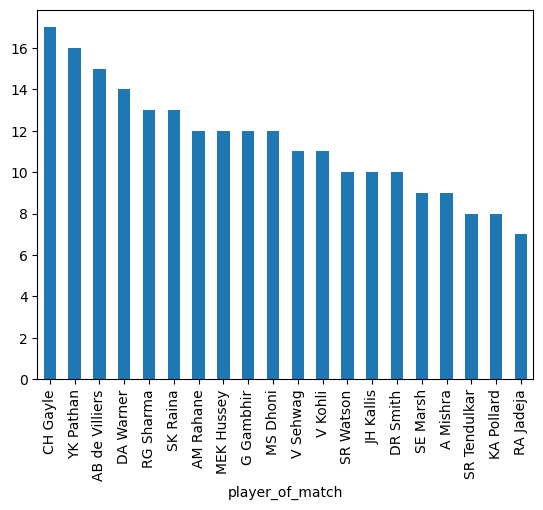

In [37]:
# Top 20 Players with Most Man of the Match Awards Graph
data['player_of_match'].value_counts()[:20].plot(kind = 'bar')

winner
Chennai Super Kings            1587
Deccan Chargers                 421
Delhi Daredevils                416
Gujarat Lions                     1
Kings XI Punjab                 796
Kochi Tuskers Kerala             23
Kolkata Knight Riders           798
Mumbai Indians                 1362
Pune Warriors                   139
Rajasthan Royals                821
Rising Pune Supergiants          53
Royal Challengers Bangalore    1150
Sunrisers Hyderabad             347
Name: win_by_runs, dtype: int64


<Axes: title={'center': 'Team Score in all seasons (win by runs)'}, xlabel='winner'>

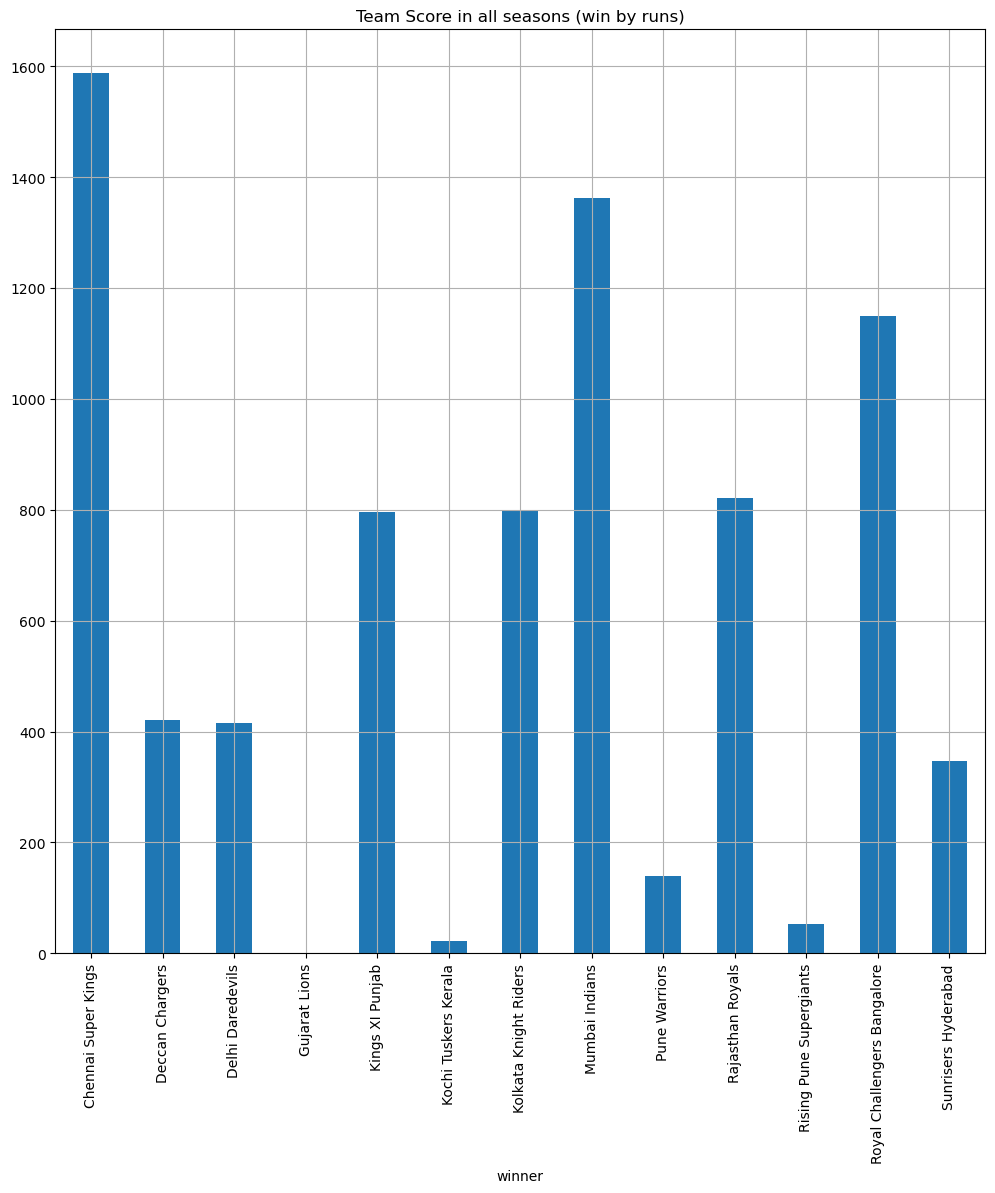

In [38]:
# Total Win by Runs for Each Team (All Seasons)
team_win_by_runs=data.groupby(by='winner').sum()['win_by_runs']
print(team_win_by_runs)

team_win_by_runs.plot(kind='bar',figsize=(12,12),grid=True,title='Team Score in all seasons (win by runs)')

winner
Chennai Super Kings            208
Deccan Chargers                 72
Delhi Daredevils               253
Gujarat Lions                   41
Kings XI Punjab                203
Kochi Tuskers Kerala            30
Kolkata Knight Riders          242
Mumbai Indians                 233
Pune Warriors                   36
Rajasthan Royals               233
Rising Pune Supergiants         20
Royal Challengers Bangalore    277
Sunrisers Hyderabad             93
Name: win_by_wickets, dtype: int64


<Axes: title={'center': 'Team Score in all seasons (win by wickets)'}, xlabel='winner'>

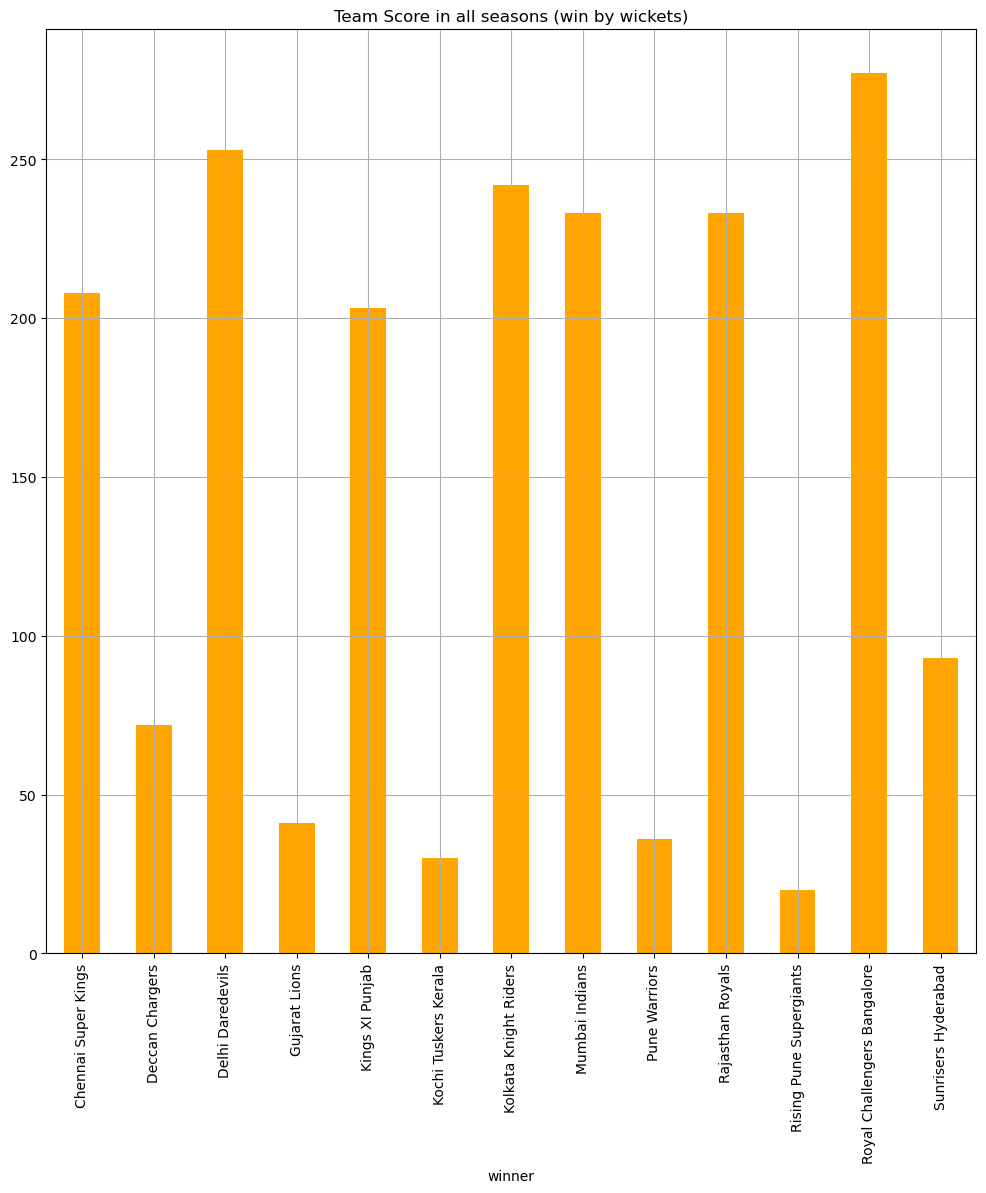

In [39]:
# Total Win by Wickets for Each Team (All Seasons)
team_win_by_wickets=data.groupby(by='winner').sum()['win_by_wickets']
print(team_win_by_wickets)

team_win_by_wickets.plot(kind='bar',figsize=(12,12),grid=True,title='Team Score in all seasons (win by wickets)',color="orange")

                             win_by_runs  win_by_wickets
winner                                                  
Chennai Super Kings            20.088608        2.632911
Deccan Chargers                14.517241        2.482759
Delhi Daredevils                7.428571        4.517857
Gujarat Lions                   0.111111        4.555556
Kings XI Punjab                12.634921        3.222222
Kochi Tuskers Kerala            3.833333        5.000000
Kolkata Knight Riders          11.735294        3.558824
Mumbai Indians                 17.025000        2.912500
Pune Warriors                  11.583333        3.000000
Rajasthan Royals               13.031746        3.698413
Rising Pune Supergiants        10.600000        4.000000
Royal Challengers Bangalore    16.428571        3.957143
Sunrisers Hyderabad            10.205882        2.735294


<Axes: title={'center': 'Team Score in all seasons'}, xlabel='winner'>

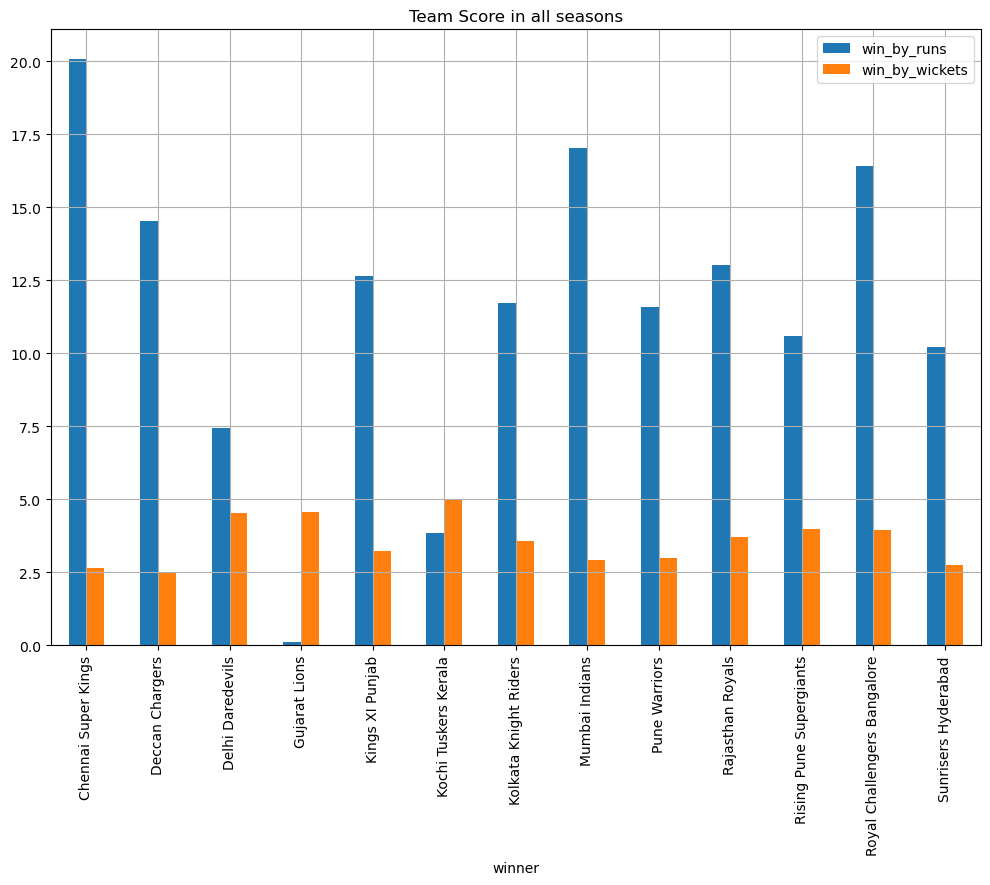

In [40]:
# Average Win Margin by Runs and Wickets (All Seasons)
overall_win_by_runs_and_wickets = (
    data.groupby('winner')[['win_by_runs', 'win_by_wickets']].mean()
)
print(overall_win_by_runs_and_wickets)

overall_win_by_runs_and_wickets.plot(kind='bar',figsize=(12,8),grid=True,title='Team Score in all seasons')

<PolarAxes: xlabel='city', ylabel='count'>

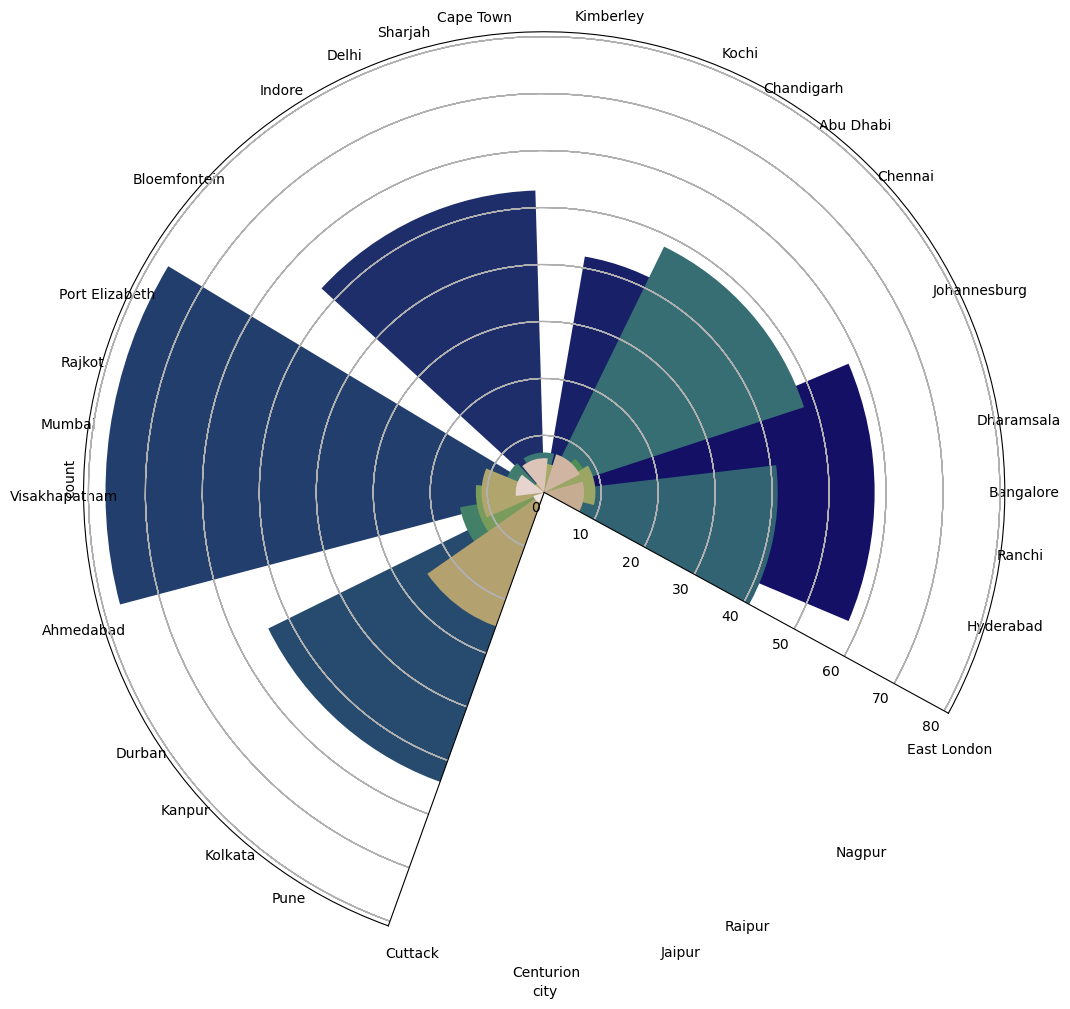

In [41]:
# Count of Matches by City
fig=plt.figure(figsize=(20,12))
plt.subplot(polar=True)
sns.countplot(x='city',data=data,palette='gist_earth')

In [42]:
# Team Statistics (Total Matches & Total Wins)
team_stats=pd.DataFrame({'TotalMatches': data.team1.value_counts()+data.team2.value_counts()
                         ,'TotalWin':data.winner.value_counts()})

team_stats=team_stats.reset_index()

team_stats.rename(columns={'index':'Teams'},inplace=True)

team_stats.head(13)

,Teams,TotalMatches,TotalWin
0,Chennai Super Kings,131,79
1,Deccan Chargers,75,29
2,Delhi Daredevils,133,56
3,Gujarat Lions,16,9
4,Kings XI Punjab,134,63
5,Kochi Tuskers Kerala,14,6
6,Kolkata Knight Riders,132,68
7,Mumbai Indians,140,80
8,Pune Warriors,46,12
9,Rajasthan Royals,118,63


## Comparing man of the match vs Venue(stadium)

In [43]:
man_of_the_match_vs_venue = data.groupby(["player_of_match",'venue','city'])['id'].count().sort_values(ascending=False)[:20]
print(man_of_the_match_vs_venue)

player_of_match  venue                                       city      
CH Gayle         M Chinnaswamy Stadium                       Bangalore     9
V Kohli          M Chinnaswamy Stadium                       Bangalore     6
DA Warner        Rajiv Gandhi International Stadium, Uppal   Hyderabad     6
AB de Villiers   M Chinnaswamy Stadium                       Bangalore     6
RG Sharma        Wankhede Stadium                            Mumbai        5
SE Marsh         Punjab Cricket Association Stadium, Mohali  Chandigarh    5
MEK Hussey       MA Chidambaram Stadium, Chepauk             Chennai       5
YK Pathan        Eden Gardens                                Kolkata       5
SK Raina         MA Chidambaram Stadium, Chepauk             Chennai       4
AM Rahane        Sawai Mansingh Stadium                      Jaipur        4
M Vijay          MA Chidambaram Stadium, Chepauk             Chennai       4
AD Russell       Eden Gardens                                Kolkata       4
KA P

In [45]:
 # Team-wise Matches Played, Wins, and Win Ratio Analysis
 won = data.groupby('winner')['id'].count().sort_values(ascending = False)
 played = []
 for t in won.index:
    played.append(len(data[(data.team1 == t) | (data.team2 == t)]))

 played = pd.Series(played, index = won.index)
 wonloss_df = pd.DataFrame({'played': played, 'won':won})
 wonloss_df['ratio'] = wonloss_df['won']/wonloss_df['played']
 print(won)
 wonloss_df.sort_values('ratio', ascending = False)

winner
Mumbai Indians                 80
Chennai Super Kings            79
Royal Challengers Bangalore    70
Kolkata Knight Riders          68
Kings XI Punjab                63
Rajasthan Royals               63
Delhi Daredevils               56
Sunrisers Hyderabad            34
Deccan Chargers                29
Pune Warriors                  12
Gujarat Lions                   9
Kochi Tuskers Kerala            6
Rising Pune Supergiants         5
Name: id, dtype: int64


,played,won,ratio
winner,,,
Chennai Super Kings,131,79,0.603053
Mumbai Indians,140,80,0.571429
Gujarat Lions,16,9,0.562500
Sunrisers Hyderabad,62,34,0.548387
Rajasthan Royals,118,63,0.533898
Kolkata Knight Riders,132,68,0.515152
Royal Challengers Bangalore,139,70,0.503597
Kings XI Punjab,134,63,0.470149
Kochi Tuskers Kerala,14,6,0.428571


## Comapring winning team vs Venue(stadium)

In [46]:
# Insight
# Consider top 20 teams and bottom 20 teams. In that Chennai super Kings is number one team.

# By doing this consider Brabourne Stadium,Mumbai.CSK had won one time and Mumbai Indians won 6 times.So that winning probability is very low for CSK to play against Mumbai Indians inBrabourne Stadium,Mumbai.

# Like this we can do for every teams particularly for young teams.

In [47]:
winner_vs_venue_top_20 = data.groupby(["winner",'venue','city'])['id'].count().sort_values(ascending=False)[:20]
print(winner_vs_venue_top_20)

winner                       venue                                         city      
Kolkata Knight Riders        Eden Gardens                                  Kolkata       33
Chennai Super Kings          MA Chidambaram Stadium, Chepauk               Chennai       33
Mumbai Indians               Wankhede Stadium                              Mumbai        29
Royal Challengers Bangalore  M Chinnaswamy Stadium                         Bangalore     29
Rajasthan Royals             Sawai Mansingh Stadium                        Jaipur        24
Delhi Daredevils             Feroz Shah Kotla                              Delhi         19
Kings XI Punjab              Punjab Cricket Association Stadium, Mohali    Chandigarh    18
Sunrisers Hyderabad          Rajiv Gandhi International Stadium, Uppal     Hyderabad     14
Mumbai Indians               Eden Gardens                                  Kolkata        8
Rajasthan Royals             Sardar Patel Stadium, Motera                  Ahmedabad  

In [46]:
winner_vs_venue_bottom_20 = data.groupby(["winner",'venue','city'])['id'].count().sort_values(ascending=True)[:20]
print(winner_vs_venue_bottom_20)

winner                 venue                                                 city          
Chennai Super Kings    Brabourne Stadium                                     Mumbai            1
Mumbai Indians         Sardar Patel Stadium, Motera                          Ahmedabad         1
                       Punjab Cricket Association IS Bindra Stadium, Mohali  Chandigarh        1
                       Newlands                                              Cape Town         1
                       Maharashtra Cricket Association Stadium               Pune              1
                       Buffalo Park                                          East London       1
Kolkata Knight Riders  Wankhede Stadium                                      Mumbai            1
                       SuperSport Park                                       Centurion         1
                       Sheikh Zayed Stadium                                  Abu Dhabi         1
                       Sharjah Cric

## Comapring Umpire vs winning team (overall)

In [50]:
# umpire1:Mumbai Indians won 80 matches overall in that 17 matches has been umpired by HDPK Dharmasena nearly its 20% in 80

# umpire2:Chennai Super Kings won 131 matches overall in that 12 matches has been umpired by SJA Taufel nearly its 10% in 180

# umpire1 and umpire2:Mumbai Indians won 80 matches overall in that 4 matches has been umpired by Asad Rauf,S Asnani nearly its 3% in 80

### Umpire1 vs winners


In [51]:
winner_vs_umpire1 = data.groupby(["winner",'umpire1'])['id'].count().sort_values(ascending=False)[:20]
print(winner_vs_umpire1)

winner                       umpire1        
Mumbai Indians               HDPK Dharmasena    17
Kings XI Punjab              HDPK Dharmasena    14
Mumbai Indians               BR Doctrove        10
                             Asad Rauf           9
Rajasthan Royals             Aleem Dar           8
Royal Challengers Bangalore  Aleem Dar           8
                             HDPK Dharmasena     8
Rajasthan Royals             BF Bowden           8
Kolkata Knight Riders        AK Chaudhary        8
Chennai Super Kings          Asad Rauf           8
Kolkata Knight Riders        Asad Rauf           7
Chennai Super Kings          Aleem Dar           7
                             HDPK Dharmasena     7
Rajasthan Royals             HDPK Dharmasena     6
Delhi Daredevils             HDPK Dharmasena     6
Kings XI Punjab              BF Bowden           6
Kolkata Knight Riders        S Ravi              6
Delhi Daredevils             BF Bowden           6
Chennai Super Kings          BR Doctr

### Umpire2 vs winners


In [52]:
winner_vs_umpire2 = data.groupby(["winner",'umpire2'])['id'].count().sort_values(ascending=False)[:20]
print(winner_vs_umpire2)

winner                       umpire2      
Chennai Super Kings          SJA Taufel       12
Mumbai Indians               SJA Taufel       12
Royal Challengers Bangalore  C Shamshuddin     9
Chennai Super Kings          C Shamshuddin     7
                             RB Tiffin         7
Mumbai Indians               VA Kulkarni       7
Royal Challengers Bangalore  S Ravi            7
Rajasthan Royals             SK Tarapore       7
Chennai Super Kings          VA Kulkarni       7
Royal Challengers Bangalore  RB Tiffin         6
Kings XI Punjab              S Ravi            6
Mumbai Indians               RJ Tucker         6
Rajasthan Royals             RJ Tucker         6
Kolkata Knight Riders        C Shamshuddin     6
Delhi Daredevils             S Ravi            6
Kolkata Knight Riders        CK Nandan         6
Royal Challengers Bangalore  DJ Harper         5
Delhi Daredevils             SJA Taufel        5
Kings XI Punjab              AM Saheba         5
Rajasthan Royals          

### Umpire1 and Umpire2 vs winners

In [53]:
winner_vs_umpire1_vs_umpire2 = data.groupby(["winner",'umpire1','umpire2'])['id'].count().sort_values(ascending=False)[:20]
print(winner_vs_umpire1_vs_umpire2)

winner                       umpire1          umpire2        
Mumbai Indians               Asad Rauf        S Asnani           4
Rajasthan Royals             S Ravi           RJ Tucker          3
Chennai Super Kings          Aleem Dar        RB Tiffin          3
Royal Challengers Bangalore  AK Chaudhary     HDPK Dharmasena    3
Kings XI Punjab              HDPK Dharmasena  PG Pathak          3
                                              CK Nandan          3
Royal Challengers Bangalore  Aleem Dar        C Shamshuddin      3
Kolkata Knight Riders        AK Chaudhary     M Erasmus          3
Mumbai Indians               HDPK Dharmasena  SJA Taufel         3
Sunrisers Hyderabad          Asad Rauf        S Asnani           3
Mumbai Indians               RK Illingworth   VA Kulkarni        3
Kolkata Knight Riders        S Ravi           C Shamshuddin      3
Mumbai Indians               BR Doctrove      SK Tarapore        3
Deccan Chargers              HDPK Dharmasena  SJA Taufel         2
